# Linear Regression from Scratch

In [1]:
import numpy as np

np.__version__

'2.2.6'

In [61]:
class SimpleLinearRegression:
    def __init__(self, B0, B1):
        self.B1 = B1
        self.B0 = B0

    def forward(self, x):
        return self.B1 * x + self.B0
    
    def set(self, w, b):
        self.B1 = w
        self.B0 = b

In [62]:
x = np.arange(1, 10, 0.5)
y = 2 * x + 1 + np.random.normal(0, 1, len(x))

In [63]:
def error(y, y_pred):
    return np.mean((y - y_pred) ** 2)

In [67]:
import matplotlib.pyplot as plt

def plot(x, y, y_pred=None, error=None):
    plt.scatter(x, y, label='Data')
    if y_pred is not None:
        plt.plot(x, y_pred, color='red', label='Prediction')
    plt.xlabel('x')
    plt.ylabel('y')
    if error is not None:
        plt.title(f'Error: {error:.2f}')
    plt.legend()
    plt.show()


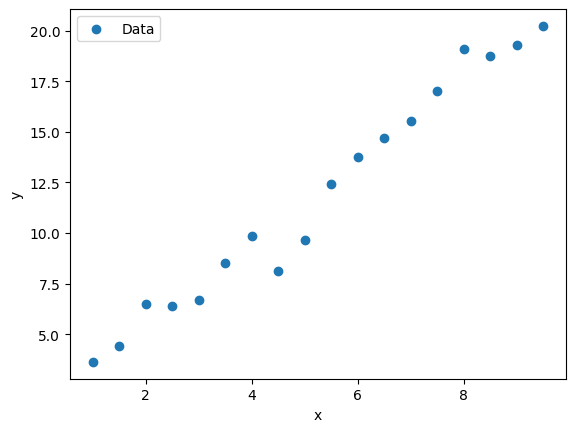

In [68]:
plot(x, y)

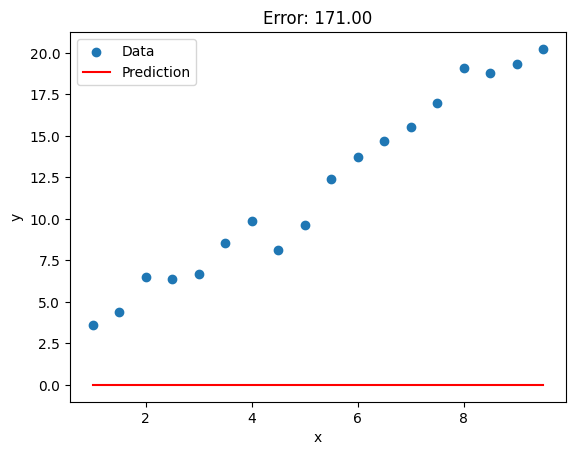

In [69]:
model = SimpleLinearRegression(0, 0)
y_pred = model.forward(x)
plot(x, y, y_pred, error(y, y_pred))

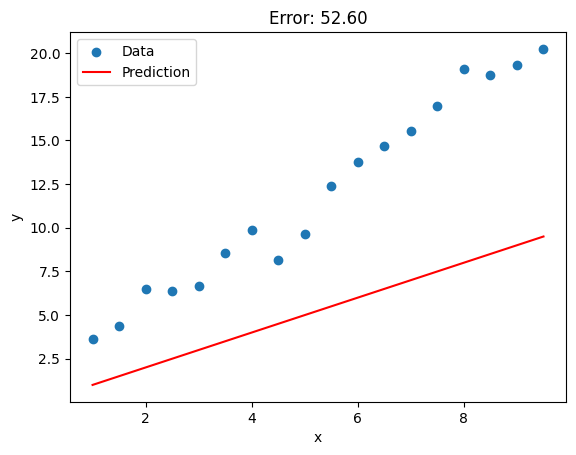

In [70]:
model.set(1, 0)
y_pred = model.forward(x)
plot(x, y, y_pred, error(y, y_pred))

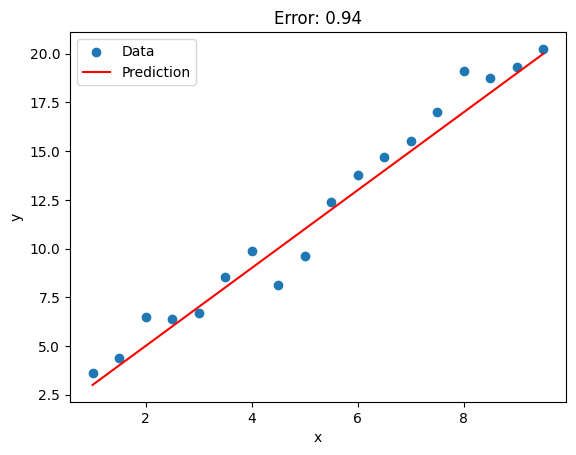

In [71]:
model.set(2, 1)
y_pred = model.forward(x)
plot(x, y, y_pred, error(y, y_pred))

In [80]:
class MultipleLinearRegression:
    def __init__(self, n_dim):
        self.coef = np.zeros(n_dim + 1)
    def forward(self, x):
        x = np.c_[np.ones(x.shape[0]), x]
        return np.dot(x, self.coef.T)
    def set(self, coef):
        self.coef = coef

In [81]:
model = MultipleLinearRegression(3)

In [82]:
x1 = np.arange(1, 10, 0.5)
x2 = np.arange(1, 10, 0.5) * 2
x3 = np.arange(1, 10, 0.5) * 3
x = np.c_[x1, x2, x3]
y = 1 + 2 * x1 + 3 * x2 + 4 * x3 + np.random.normal(0, 10, len(x1))

In [83]:
def plot_multiple(x, y, y_pred=None, error=None):
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(x[:, 0], x[:, 1], y, label='Data')
    if y_pred is not None:
        ax1.plot3D(x[:, 0], x[:, 1], y_pred, color='red', label='Prediction')
    ax1.set_xlabel('x1')
    ax1.set_ylabel('x2')
    ax1.set_zlabel('y')
    if error is not None:
        ax1.set_title(f'Error: {error:.2f}')
    ax1.legend() 
    plt.show()

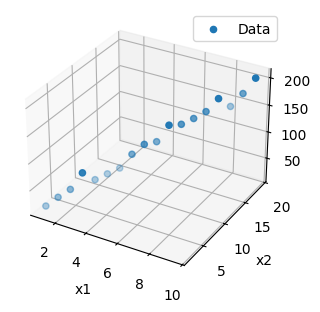

In [84]:
plot_multiple(x, y)

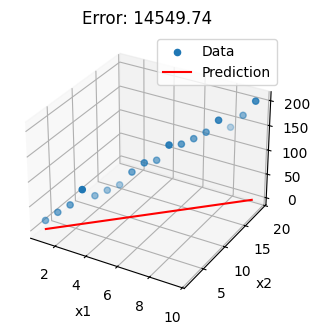

In [85]:
y_pred = model.forward(x)
plot_multiple(x, y, y_pred, error(y, y_pred))

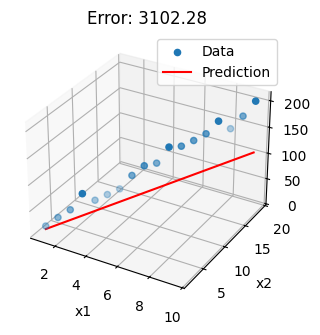

In [87]:
model.set(np.array([1, 1, 2, 2]))
y_pred = model.forward(x)
plot_multiple(x, y, y_pred, error(y, y_pred))

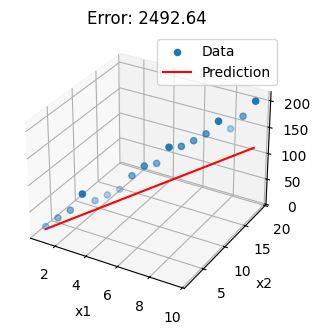

In [89]:
model.set(np.array([1, 1, 1, 3]))
y_pred = model.forward(x)
plot_multiple(x, y, y_pred, error(y, y_pred))

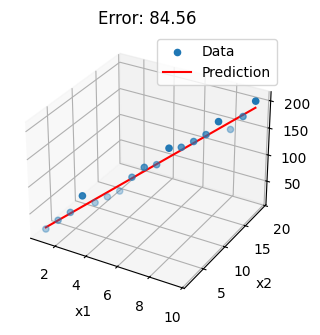

In [91]:
model.set(np.array([1, 2, 3, 4]))
y_pred = model.forward(x)
plot_multiple(x, y, y_pred, error(y, y_pred))